Task 2: Model Building & Training
imports and data loading

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import os

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    average_precision_score,
    precision_recall_curve,
    roc_auc_score
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
os.makedirs('../models', exist_ok=True)
X_train_f = pd.read_csv('../data/processed/fraud_X_train.csv')
y_train_f = pd.read_csv('../data/processed/fraud_y_train.csv').squeeze()
X_test_f  = pd.read_csv('../data/processed/fraud_X_test.csv')
y_test_f  = pd.read_csv('../data/processed/fraud_y_test.csv').squeeze()

print("Fraud_Data train shape:", X_train_f.shape)
print("Fraud_Data test shape: ", X_test_f.shape)
print("Train class dist:\n", y_train_f.value_counts())
X_train_c = pd.read_csv('../data/processed/cc_X_train.csv')
y_train_c = pd.read_csv('../data/processed/cc_y_train.csv').squeeze()
X_test_c  = pd.read_csv('../data/processed/cc_X_test.csv')
y_test_c  = pd.read_csv('../data/processed/cc_y_test.csv').squeeze()

print("Creditcard train shape:", X_train_c.shape)
print("Creditcard test shape: ", X_test_c.shape)
print("Train class dist:\n", y_train_c.value_counts())

Fraud_Data train shape: (219136, 199)
Fraud_Data test shape:  (30223, 199)
Train class dist:
 class
0    109568
1    109568
Name: count, dtype: int64
Creditcard train shape: (454902, 30)
Creditcard test shape:  (56962, 30)
Train class dist:
 Class
0    227451
1    227451
Name: count, dtype: int64


helper functions

In [19]:
import sys
sys.path.append('../src')

from helper import evaluate_model, plot_pr_curve

Logistic Regression Baseline

Interpretable baseline. Trained with class_weight='balanced' as an
extra guard on the raw test set distribution.


  Logistic Regression — Fraud_Data
  F1-Score        : 0.6649
  AUC-PR          : 0.6306
  ROC-AUC         : 0.8099

              precision    recall  f1-score   support

       Legit       0.95      0.99      0.97     27393
       Fraud       0.88      0.53      0.66      2830

    accuracy                           0.95     30223
   macro avg       0.92      0.76      0.82     30223
weighted avg       0.95      0.95      0.94     30223



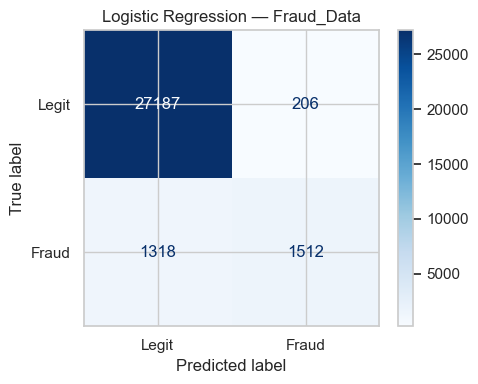

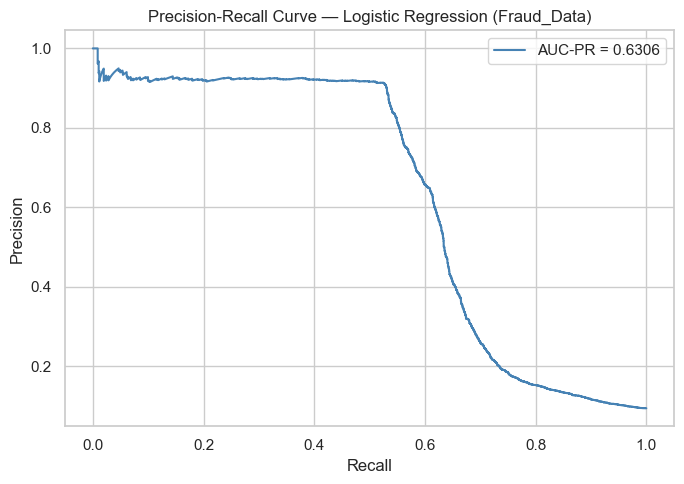

In [20]:
lr_fraud = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr_fraud.fit(X_train_f, y_train_f)

lr_fraud_metrics = evaluate_model(lr_fraud, X_test_f, y_test_f,
                                   model_name="Logistic Regression",
                                   dataset_name="Fraud_Data")
plot_pr_curve(lr_fraud, X_test_f, y_test_f, "Logistic Regression", "Fraud_Data")

Train LR on creditcard


  Logistic Regression — creditcard
  F1-Score        : 0.1088
  AUC-PR          : 0.7245
  ROC-AUC         : 0.9708

              precision    recall  f1-score   support

       Legit       1.00      0.97      0.99     56864
       Fraud       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962



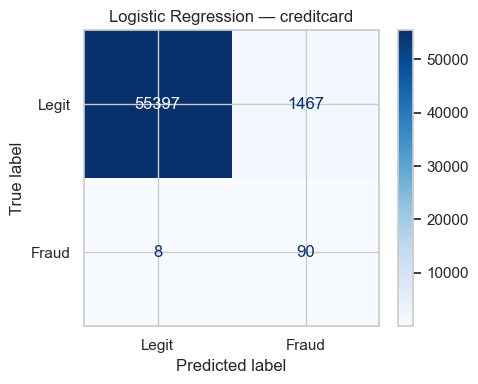

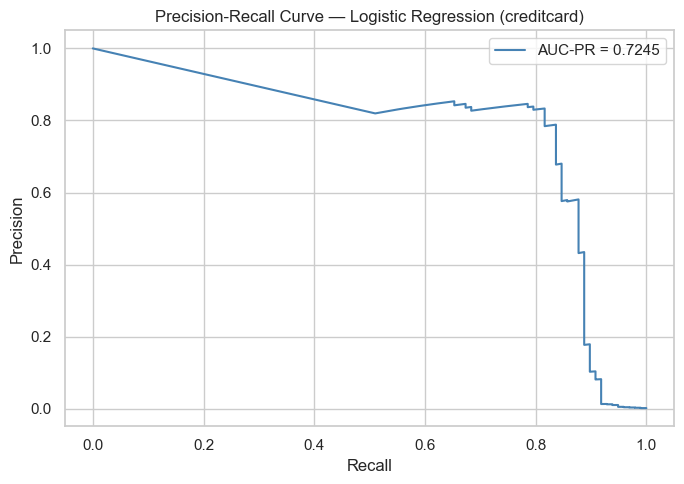

In [21]:
lr_cc = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr_cc.fit(X_train_c, y_train_c)

lr_cc_metrics = evaluate_model(lr_cc, X_test_c, y_test_c,
                                model_name="Logistic Regression",
                                dataset_name="creditcard")
plot_pr_curve(lr_cc, X_test_c, y_test_c, "Logistic Regression", "creditcard")

3. XGBoost Ensemble Model

XGBoost is chosen for its:
- Strong performance on tabular, imbalanced data
- Built-in feature importance (used in Task 3 SHAP analysis)
- scale_pos_weight handles remaining imbalance on test distribution

 Train XGBoost on Fraud_Data


  XGBoost — Fraud_Data
  F1-Score        : 0.6791
  AUC-PR          : 0.7056
  ROC-AUC         : 0.8371

              precision    recall  f1-score   support

       Legit       0.96      0.99      0.97     27393
       Fraud       0.87      0.56      0.68      2830

    accuracy                           0.95     30223
   macro avg       0.91      0.77      0.83     30223
weighted avg       0.95      0.95      0.95     30223



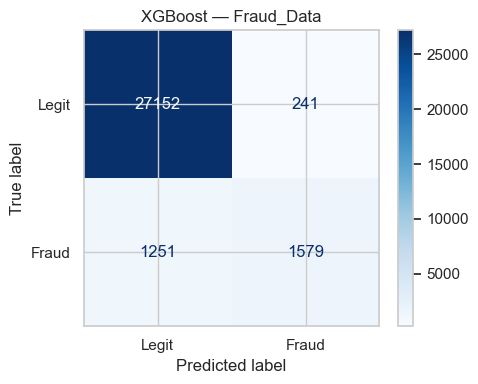

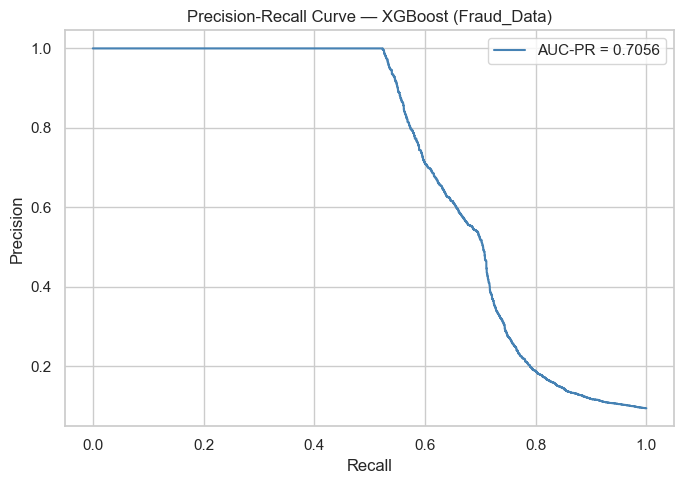

In [22]:
neg = (y_train_f == 0).sum()
pos = (y_train_f == 1).sum()
spw = neg / pos  # will be ~1.0 after SMOTE but good practice to set

xgb_fraud = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=spw,
    eval_metric='aucpr',
    random_state=42,
    verbosity=0
)
xgb_fraud.fit(X_train_f, y_train_f)

xgb_fraud_metrics = evaluate_model(xgb_fraud, X_test_f, y_test_f,
                                    model_name="XGBoost",
                                    dataset_name="Fraud_Data")
plot_pr_curve(xgb_fraud, X_test_f, y_test_f, "XGBoost", "Fraud_Data")

Train XGBoost on creditcard


  XGBoost — creditcard
  F1-Score        : 0.6566
  AUC-PR          : 0.8626
  ROC-AUC         : 0.9776

              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56864
       Fraud       0.52      0.89      0.66        98

    accuracy                           1.00     56962
   macro avg       0.76      0.94      0.83     56962
weighted avg       1.00      1.00      1.00     56962



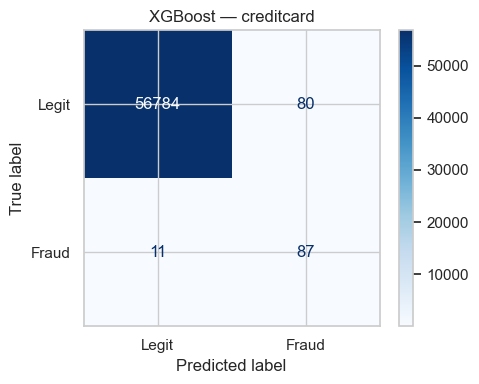

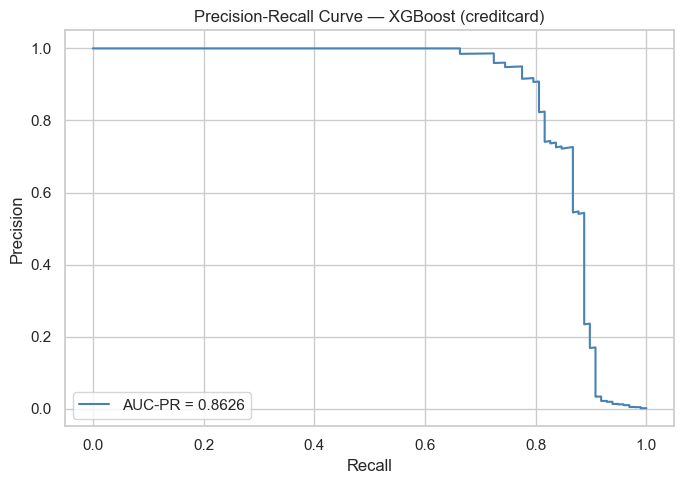

In [23]:
neg_c = (y_train_c == 0).sum()
pos_c = (y_train_c == 1).sum()
spw_c = neg_c / pos_c

xgb_cc = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=spw_c,
    eval_metric='aucpr',
    random_state=42,
    verbosity=0
)
xgb_cc.fit(X_train_c, y_train_c)

xgb_cc_metrics = evaluate_model(xgb_cc, X_test_c, y_test_c,
                                 model_name="XGBoost",
                                 dataset_name="creditcard")
plot_pr_curve(xgb_cc, X_test_c, y_test_c, "XGBoost", "creditcard")

4. Stratified K-Fold Cross-Validation (k=5)

Cross-validation is run on the original pre-SMOTE training data
to get unbiased performance estimates. SMOTE is NOT applied inside CV
folds here for simplicity — a pipeline approach would apply it per fold.

cv on fraud_data

In [24]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['f1', 'average_precision', 'roc_auc']

X_train_f_orig = pd.read_csv('../data/processed/fraud_X_test.csv')  
from sklearn.model_selection import train_test_split
fraud_clean = pd.read_csv('../data/processed/fraud_X_train.csv')  

cv_results_fraud = cross_validate(
    XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.05,
                  random_state=42, verbosity=0),
    X_train_f, y_train_f,
    cv=skf, scoring=scoring, n_jobs=-1
)

print("=== Fraud_Data — XGBoost 5-Fold CV ===")
for metric in scoring:
    scores = cv_results_fraud[f'test_{metric}']
    print(f"  {metric:25s}: {scores.mean():.4f} ± {scores.std():.4f}")

=== Fraud_Data — XGBoost 5-Fold CV ===
  f1                       : 0.9447 ± 0.0009
  average_precision        : 0.9857 ± 0.0003
  roc_auc                  : 0.9797 ± 0.0005


cv on creditcard

In [25]:
cv_results_cc = cross_validate(
    XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.05,
                  random_state=42, verbosity=0),
    X_train_c, y_train_c,
    cv=skf, scoring=scoring, n_jobs=-1
)

print("=== creditcard — XGBoost 5-Fold CV ===")
for metric in scoring:
    scores = cv_results_cc[f'test_{metric}']
    print(f"  {metric:25s}: {scores.mean():.4f} ± {scores.std():.4f}")

=== creditcard — XGBoost 5-Fold CV ===
  f1                       : 0.9992 ± 0.0001
  average_precision        : 1.0000 ± 0.0000
  roc_auc                  : 1.0000 ± 0.0000


5. Model Comparison & Selection
   comparision table

In [26]:
all_metrics = [lr_fraud_metrics, xgb_fraud_metrics,
               lr_cc_metrics,    xgb_cc_metrics]

results_df = pd.DataFrame(all_metrics)
results_df = results_df.sort_values(['dataset', 'AUC-PR'], ascending=[True, False])
results_df.reset_index(drop=True, inplace=True)

print(results_df.to_string(index=False))

              model    dataset     F1  AUC-PR  ROC-AUC
            XGBoost Fraud_Data 0.6791  0.7056   0.8371
Logistic Regression Fraud_Data 0.6649  0.6306   0.8099
            XGBoost creditcard 0.6566  0.8626   0.9776
Logistic Regression creditcard 0.1088  0.7245   0.9708


visual comparison

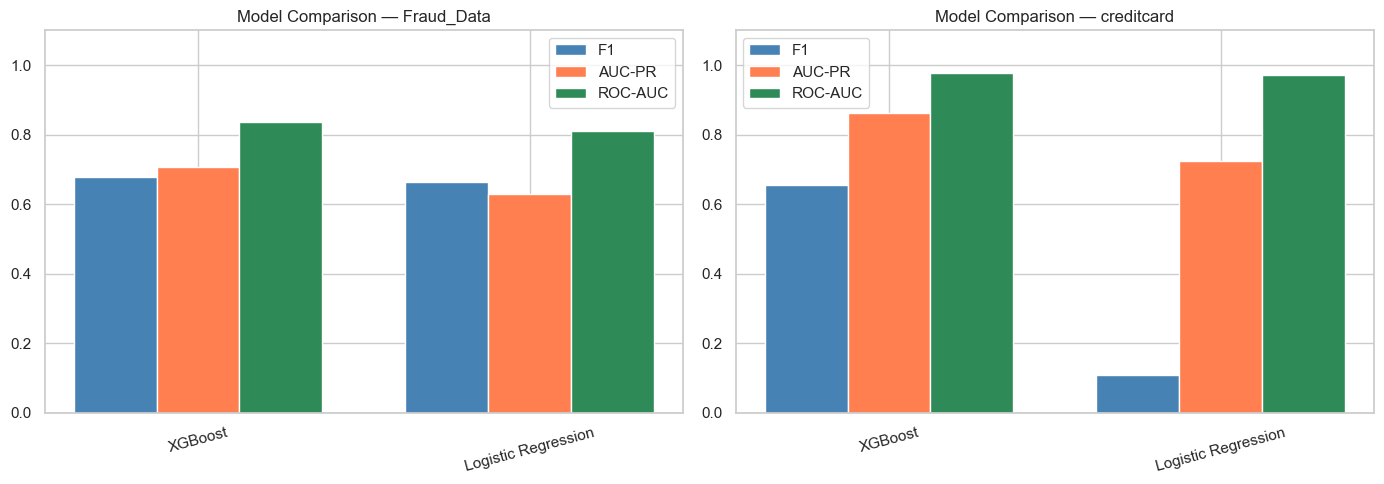

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, dataset in zip(axes, ['Fraud_Data', 'creditcard']):
    subset = results_df[results_df['dataset'] == dataset]
    x = np.arange(len(subset))
    width = 0.25

    ax.bar(x - width, subset['F1'],      width, label='F1',      color='steelblue')
    ax.bar(x,          subset['AUC-PR'], width, label='AUC-PR',  color='coral')
    ax.bar(x + width,  subset['ROC-AUC'],width, label='ROC-AUC', color='seagreen')

    ax.set_xticks(x)
    ax.set_xticklabels(subset['model'], rotation=15)
    ax.set_ylim(0, 1.1)
    ax.set_title(f'Model Comparison — {dataset}')
    ax.legend()

plt.tight_layout()
plt.show()

save the best models

In [28]:
joblib.dump(xgb_fraud, '../models/xgb_fraud.pkl')
joblib.dump(xgb_cc,    '../models/xgb_cc.pkl')

print("Models saved to ../models/")

Models saved to ../models/


Model Selection — Justification

 Selected Model: XGBoost

Performance:
- XGBoost outperforms Logistic Regression on both AUC-PR and F1 across
  both datasets, which are the primary metrics for imbalanced fraud detection.
- AUC-PR is prioritized over ROC-AUC because it is more informative when
  the positive class (fraud) is rare — ROC-AUC can be misleadingly optimistic.

Why not Logistic Regression:
- LR assumes linear decision boundaries, which is insufficient for the
  complex, non-linear interactions between behavioral features (e.g.
  time_since_signup × device_tx_count × country).
- LR is retained as a documented baseline for comparison.

Why XGBoost over Random Forest:
- XGBoost trains faster and handles the scale_pos_weight parameter natively.
- XGBoost's boosting approach iteratively focuses on hard-to-classify
  fraud cases, which is well-suited to the extreme imbalance in creditcard.csv.
- XGBoost produces SHAP-compatible output natively, supporting Task 3.

